In [ ]:
# add packages/dependencies
using ImagePhantoms
using ImageGeoms: ImageGeom
using Plots
using MIRTjim
using NFFT
using LinearMapsAA
using Random
using LaTeXStrings

In [ ]:
# set phantom parameters
N = 256; # image size (NxN)
fov = 200; # FOV (mm)
tr = 62.5; # spoke TR (ms, matches looping star)
t_act = 20; # task on time (s)
act_lvl = 0.05; # activation level (fractional signal change)
noise_lvl = 0.1; # noise level (std. dev. of additive complex Gaussian noise)

# set sampling parameters
nspokes = 4800; # total number of spokes

# sliding window parameters
kr_0 = 0.25; # sliding window aperature transition band start (fraction of k-space radius)
a_0 = 32; # sliding window aperature from |k| = [0, kr_0] (in number of spokes)
kr_edge = 0.75; # sliding window aperature transition band end (fraction of k-space radius)
a_edge = 64; # sliding window aperature from |k| = [kr_edge, 1] (in number of spokes)
stride = 32; # sliding window stride (in number of spokes)
window_type = "binary"; # "binary" or "gaussian"
window_shape = 2; # polynomial order for window width

In [113]:
# create phantom
ig = ImageGeom(dims=(N, N), deltas=(fov/N, fov/N))
objects = shepp_logan(SheppLoganToft(); fovs=(fov, fov))
image = phantom(axes(ig)..., objects[1:9])
act_mask = phantom(axes(ig)..., objects[10:10]) .> 0

ov1 = ovLayer(image, (0,1));
ov2 = ovLayer(act_mask, (0,1), color=:hot);
ov = ovshow([ov1,ov2]);
cm1 = cgrad([:black, :white, :white, :red])          # color gradient object
# combine the underlying color arrays and create a new gradient
# cm3 = cgrad(vcat(cm1.colors, cm2.colors))
jim(axes(ig)..., ov["img_all"], color=cm1, axis=false, colorbar=false, margin=-20Plots.mm,
size=(500,500))
savefig("~/Desktop/phantom.png")

"/Users/djfrey/Desktop/phantom.png"

In [126]:
# create the task waveform
t = tr * 1e-3 / (2 * N) * (0:(2*N*nspokes-1)); # total time vector
task = reshape(fmri_act(t, t_act, t_act, 0), 2 * N, nspokes);
plot(t, act_lvl*100 * task[:], xlabel="time (s)", ylabel="signal (% change)", 
    xlabelfontsize = 14,
    ylabelfontsize = 14,
    label=false, lw = 4, color=:red,
    background_color = :transparent)
savefig("~/Desktop/task_waveform.png")

"/Users/djfrey/Desktop/task_waveform.png"

In [127]:
# create sampling trajectory and simulate k-space data
φ = pi*(3-sqrt(5))  # golden angle in radians
ktraj_raw = Array{Float32}(undef, 2*N, nspokes, 2)
for s in 1:nspokes
    ktraj_raw[:,s,:] = range(-N/fov/2, N/fov/2, 2 * N) .* [cos(s * φ), sin(s * φ)]'
end

# plot sampling trajectory
nspokes_show = 20
for i in 1:2:100
    plt = plot(fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 1], fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 2],
        label=nothing,
        xlabel=L"\omega_x", ylabel=L"\omega_y", xlabelfontsize=18, ylabelfontsize=18,
        xticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        yticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        lw=4,
        aspect_ratio=1,
        color=:blue,
        background_color = :transparent,
        size=(500, 500))
    for j in (i+nspokes_show-1:-1:1)
        plot!(plt,
            fov / N * 2 * ktraj_raw[:, j, 1], fov / N * 2 * ktraj_raw[:, j, 2],
            lw = 4,
            color=:blue,
            alpha=j/(i+nspokes_show),
            label=nothing)
    end
    savefig(plt, "~/Desktop/radial_sampling/frame_$(ceil(Int,i/2)).png")
end


In [116]:
# simulate the k-space data using the analytical Fourier transform of the phantom
kdata_raw = Array{ComplexF32}(undef, 2 * N, nspokes);
spec_bkg = spectrum(objects[1:9]); spec_act = spectrum(objects[10]);
for s in 1:nspokes
    kdata_raw[:,s] = spec_bkg.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]); # background component
    kdata_raw[:,s] .+= act_lvl * task[:,s] .* spec_act.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]) # activation component
end

# add complex Gaussian noise
Random.seed!(0) # for reproducibility
kdata_raw .+= noise_lvl/sqrt(2) * (randn(ComplexF32, size(kdata_raw)) .+ im * randn(ComplexF32, size(kdata_raw)));

In [117]:
# split data into windows
a_max = max(a_0, a_edge); # maximum window aperature
M = 2 * N * a_max; # number of measurements per frame
nframes = floor(Int, (nspokes - a_max) / stride) + 1 # total number of frames
ktraj = Array{Float32}(undef, M, nframes, 2) # windowed k-space traj
b = Array{ComplexF32}(undef, M, nframes) # window widths
for f in 1:nframes
    win_idcs = collect(1:a_max) .+ (f-1)*stride
    ktraj[:,f,:] = reshape(ktraj_raw[:, win_idcs, :], M, 2)
    b[:,f] = vec(kdata_raw[:, win_idcs])
end

In [ ]:
# create aperature shaping function
ζ = x -> begin
    if x < kr_0
        return a_0
    elseif x < kr_edge
        return (x - kr_0)^window_shape / (kr_edge - kr_0)^window_shape * (a_edge - a_0) + a_0
    else
        return a_edge
    end
end

# set up windowing function
if window_type == "binary"
    window = (tc, t, kr) -> begin # binary windowing function
        return 1.0 * (abs(t - tc) <= 1/2 * ζ(2 * fov / N * kr))
    end
    window_color = :grays
elseif window_type == "gaussian"
    window = (tc, t, kr) -> begin # gaussian windowing function
        return exp(-sqrt(2 * log(2)) * ((t - tc) / ζ(2 * fov / N * kr))^2)
    end
    window_color = :viridis
end

:grays

In [119]:
# set up frame-wise NUFFT operators
nuffts = Vector{Any}(undef, nframes)
for f in 1:nframes
    ω = 2*pi*fov/N * ktraj[:,f,:]
    nuffts[f] = plan_nfft(ω' / (2 * pi), (N, N); m=4, σ=2.0) # create NFFT plan
end

# set up the acquisition model
A = LinearMapAA(
    x -> begin
        y = zeros(eltype(x),(M,nframes));
        for f in 1:nframes
            y[:,f] = nuffts[f] * x[:,:,f]
        end
        return y
    end,
    y -> begin
        x = zeros(eltype(y),(N,N,nframes));
        for f in 1:nframes
            x[:,:,f] = adjoint(nuffts[f]) * y[:,f]
        end
        return x
    end,
    (M*nframes, N^2*nframes), 
    idim=(N,N,nframes),
    odim=(M,nframes)
)

# set up the windowing operator
t_win = range(-a_max / 2, a_max / 2, M)
W = LinearMapAA(
    x -> x .* window.(0, t_win, sqrt.(sum(ktraj.^2, dims=3))), # reference to center of window (t=0)
    x -> x .* window.(0, t_win, sqrt.(sum(ktraj.^2, dims=3))),
    (M*nframes, M*nframes),
    idim=(M,nframes),
    odim=(M,nframes)
)

# create normal equations terms
AHWHWA = LinearMapAA( # (WA)'*(WA)
    x -> A' * (W' * (W * (A * x))),
    x -> A' * (W' * (W * (A * x))),
    (N^2*nframes, N^2*nframes),
    idim=(N,N,nframes),
    odim=(N,N,nframes)
)
AHWHWb = A'*(W' * (W * b)); # (WA)'*Wb
x0 = zeros(eltype(b), (N,N,nframes)) # initialize to zeros

# solve the reconstruction problem
x_star = cg(AHWHWA, x0, AHWHWb; verbose=true);

cg initialization:  residual norm =  1.035e+09,  time =   10.853s
cg iteration    1:  residual norm =  1.290e+08,  time =   10.229s
cg iteration    2:  residual norm =  6.138e+07,  time =    9.519s
cg iteration    3:  residual norm =  4.309e+07,  time =    9.437s
cg iteration    4:  residual norm =  4.480e+07,  time =    9.469s
cg iteration    5:  residual norm =  2.442e+07,  time =    9.903s
cg iteration    6:  residual norm =  1.319e+07,  time =    9.976s
cg iteration    7:  residual norm =  1.076e+07,  time =    9.750s
cg iteration    8:  residual norm =  9.286e+06,  time =    9.570s
cg iteration    9:  residual norm =  6.306e+06,  time =    9.338s
cg iteration   10:  residual norm =  4.469e+06,  time =    9.037s
cg iteration   11:  residual norm =  3.394e+06,  time =    9.518s
cg iteration   12:  residual norm =  4.566e+06,  time =    9.152s
cg iteration   13:  residual norm =  3.219e+06,  time =    9.269s
cg iteration   14:  residual norm =  2.687e+06,  time =    9.127s
cg iterati

In [122]:
for f in 1:50
    # show the reconned frame
    prec = jim(axes(ig)..., x_star[:, :, f], clim=(0, 0.7), xticks=false, yticks=false, colorbar=false,
        size=(500,500), margin=-20Plots.mm)
    annotate!(prec, axes(ig)[1][1], axes(ig)[2][1], ("frame $f", 12, :white, :left, :bottom), bg=:black)
    savefig(prec, "~/Desktop/wls_recon/frame_$f.png")
end

In [123]:
# calculate the t-score map
t_hat = tr * 1e-3 * (a_max / 2 .+ stride * (0:nframes-1)) # center time of each frame (s)
GLM = fmri_act(t_hat, t_act, t_act, 0) .^ [0, 1]'; # [baseline, task]
(tscore, ~) = fmri_tscore(GLM, x_star);

In [124]:
# calculate ROC curve and AUC
nthresh = 100; # number of t-score thresholds to test
tscore_max = max(maximum(tscore[:, :, 2][act_mask]), maximum(tscore[:, :, 2][.!act_mask]))
tscore_thresh = range(tscore_max,0,nthresh); # t-score thresholds to test
TPR = Vector{Float32}(undef,nthresh);
FPR = Vector{Float32}(undef,nthresh);
for i in 1:nthresh
    ntp = count(tscore[:, :, 2][act_mask] .>= tscore_thresh[i]) # number of true positives
    nfn = count(tscore[:, :, 2][act_mask] .< tscore_thresh[i]) # number of false negatives
    nfp = count(tscore[:, :, 2][.!act_mask] .>= tscore_thresh[i]) # number of false positives
    ntn = count(tscore[:, :, 2][.!act_mask] .< tscore_thresh[i]) # number of true negatives
    TPR[i] = ntp / (ntp + nfn); # true positive rate
    FPR[i] = nfp / (nfp + ntn); # false positive rate
end
# append (0,0) and (1,1) to each axis
FPR_full = vcat(0.0, FPR, 1.0)
TPR_full = vcat(0.0, TPR, 1.0)

# compute AUC using trapezoidal rule
AUC = sum(0.5 * (TPR_full[2:end] + TPR_full[1:end-1]) .* (FPR_full[2:end] - FPR_full[1:end-1]));

# get the mean signal from the roi
mean_signal_roi = 1/count(act_mask) * vcat([sum(abs.(x_star[:,:,i])[act_mask]) for i in 1:nframes]...);

In [130]:
# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    background_color = :transparent,
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))
savefig(proc, "~/Desktop/roc_curve.png")

"/Users/djfrey/Desktop/roc_curve.png"

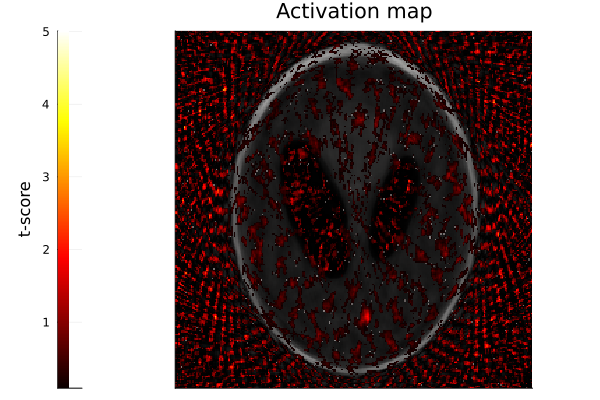

In [ ]:
# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false)
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl, background_color = :transparent, layout=@layout [a{0.1w} b{0.9w}])

In [126]:
show_plots = false # set to true if you want to see the plots :)

# show the windowing functions
ncycles_show = 10
kr_show = range(0, N / fov / 2, 100)
t_show = range(0, min(t[end], t_act*ncycles_show), 1000)
normalize = x -> (x .- minimum(x)) ./ (maximum(x) - minimum(x))

# display the task waveform and mean signal in roi
psig = plot(t_show, normalize(fmri_act(t_show,t_act,t_act,0)), label="task",
    xlabel="time (s)", ylabel="signal",
    ylim=(0,1), yticks=false
)
plot!(psig, t_hat, normalize(mean_signal_roi),
    label="mean signal (roi)",
    xlim=(0, t_act*ncycles_show)
)

# show the windowing functions
t_sub = range(-tr*1e-3, (a_max + stride + 1)*tr*1e-3, 100)
pwin = plot(
    heatmap(t_sub, kr_show, window.(t_hat[1] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xticks=false, xlabel=nothing, title="frame 1 windowing function"), # 1st frame
    heatmap(t_sub, kr_show, window.(t_hat[2] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xlabel="time(s)", title="frame 2 windowing function"), # 2nd frame
    layout = (2,1),
    ylim=(0, N / fov / 2),
    color=window_color, colorbar=false,
    ylabel=L"|k|",
    yticks=((0, N / fov / 2), ("0", L"k_\mathrm{max}")))

# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false,
    title="Activation map")
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl,  layout=@layout [a{0.1w} b{0.9w}])

# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    title="ROC Curve",
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))

if show_plots
    # save a big ol figure with all the results
    @gif for f in 1:min(nframes,50)
        # show the reconned frame
        prec = jim(axes(ig)..., x_star[:, :, f], clim=(0, 0.7), xticks=false, yticks=false, colorbar=false,
            title="frame-wise recon")
        annotate!(prec, axes(ig)[1][1], axes(ig)[2][1], ("frame $f", 12, :white, :left, :bottom), bg=:black)

        # plot all
        p_sub2 = plot(pwin, prec, layout=@layout [a{0.5w} b{0.5w}])
        p_sub3 = plot(proc, pact, layout=@layout [a{0.4w} b{0.6w}])
        plot(
            psig,
            p_sub2,
            p_sub3,
            size=(900, 1200),
            layout=@layout [a{0.2h}; b{0.4h}; c{0.4h}]
        );
    end
end